# 03 — São Paulo e recorte regional
A célula mais próxima de −23,5505°, −46,6333° representa uma estimativa em grade. Não se trata de estação de monitoramento.

In [3]:
from pathlib import Path
from cams_air_quality.config import load_config
ROOT = Path.cwd() if (Path.cwd() / "config/config.yaml").exists() else Path.cwd().parent
cfg = load_config(ROOT / "config/config.yaml")


In [4]:
from cams_air_quality.extraction import get_timeseries, get_region_timeseries, save_table
sp = get_timeseries(cfg, pollutant="pm25", lat=-23.5505, lon=-46.6333)
print(sp.attrs)
sp.head()

{'dataset': 'cams-global-reanalysis-eac4-monthly', 'history': 'annual immutable Zarr partition; no spatial interpolation', 'months_present': '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]', 'provenance_manifest': '[{"key": "4e79bce714a8e6afba25ccd3415d6ba14b43687efb90a1a429c048d4b43f5331", "filepath": "/home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/data/raw/eac4/monthly/co/2003/01/co_2003-01_4e79bce714a8.grib", "checksum": "be58fa7626d9fa5edc7697e641642e7bda924e5322c8382a6d2e72cafcb6752b", "processed_path": "/home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/data/processed/eac4/monthly/co/2003/01_4e79bce714a8_be5a06906fda3b10.nc", "processed_checksum": "e092fa68631549f4b076a46ab2ca518ed9fb2995f677e558b98481ee1d57e53c"}, {"key": "06414146cbcef0344d74fa1c800448d010c1fb989fce5e7f6a092ea063c756c8", "filepath": "/home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/data/raw/eac4/monthly/no2/2003/01/no2_2003-01_06414146cbce.grib", "checksum": "977ffd90f2b

,time,latitude,longitude,pm25
0,2003-01-01,-23.25,313.5,39.961689
1,2003-02-01,-23.25,313.5,51.366573
2,2003-03-01,-23.25,313.5,45.036602
3,2003-04-01,-23.25,313.5,67.257507
4,2003-05-01,-23.25,313.5,73.076752


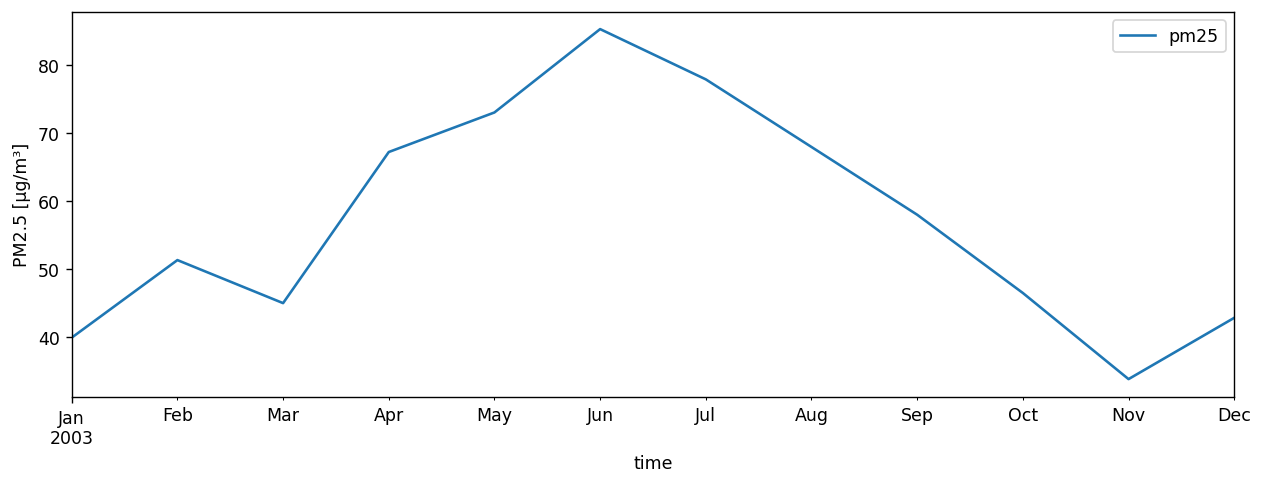

In [5]:
sp.plot(x="time", y="pm25", figsize=(12,4), ylabel="PM2.5 [µg/m³]")
save_table(sp, ROOT / "reports/sao_paulo_pm25.parquet")

In [6]:
region = get_region_timeseries(cfg, pollutant="no2", bbox=[-20, -50, -26, -43])
print(region.attrs)
save_table(region, ROOT / "reports/regional_no2.csv")
region.head()

{'GRIB_NV': 122, 'GRIB_Nx': 480, 'GRIB_Ny': 241, 'GRIB_cfName': 'mass_fraction_of_nitrogen_dioxide_in_air', 'GRIB_cfVarName': 'no2', 'GRIB_dataType': 'an', 'GRIB_gridDefinitionDescription': 'Latitude/longitude', 'GRIB_gridType': 'regular_ll', 'GRIB_iDirectionIncrementInDegrees': 0.75, 'GRIB_iScansNegatively': 0, 'GRIB_jDirectionIncrementInDegrees': 0.75, 'GRIB_jPointsAreConsecutive': 0, 'GRIB_jScansPositively': 0, 'GRIB_latitudeOfFirstGridPointInDegrees': 90.0, 'GRIB_latitudeOfLastGridPointInDegrees': -90.0, 'GRIB_level': 60, 'GRIB_longitudeOfFirstGridPointInDegrees': 0.0, 'GRIB_longitudeOfLastGridPointInDegrees': 359.25, 'GRIB_missingValue': 3.4028234663852886e+38, 'GRIB_name': 'Nitrogen dioxide mass mixing ratio', 'GRIB_numberOfPoints': 115680, 'GRIB_paramId': 210121, 'GRIB_shapeOfTheEarth': 6, 'GRIB_shortName': 'no2', 'GRIB_stepType': 'avgd', 'GRIB_stepUnits': 1, 'GRIB_typeOfLevel': 'hybrid', 'GRIB_units': 'kg kg**-1', 'GRIB_uvRelativeToGrid': 0, 'assumptions': 'Lowest EAC4 hybrid m

,time,no2
0,2003-01-01,2.734245e-09
1,2003-02-01,3.423009e-09
2,2003-03-01,2.718476e-09
3,2003-04-01,3.450421e-09
4,2003-05-01,3.759581e-09


O bbox usa centros das células, inclusive suporte a cruzar o antimeridiano na extração. A média regional é ponderada por área. O JSON ao lado do CSV/Parquet registra unidades e os metadados disponíveis.